# Quickstart: Surface Albedo

Surface albedo testing with pyradtran.

In [1]:
# Import PyRadtran components
from pyradtran.interface import PyRadtranAccessor
from pyradtran.config import SimulationConfig, PathsConfig, SimulationDefaults
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

# Configure logging
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

# Define configuration programmatically
config = SimulationConfig(
    paths=PathsConfig(
        libradtran_bin=Path('/opt/libradtran/2.0.4/bin/uvspec'),
        libradtran_data=Path('/opt/libradtran/2.0.4/share/libRadtran/data'),
        atmosphere_profile=Path('/projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat'),
        solar_spectrum=Path('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat'),
        output_dir=Path('work')
    ),
    simulation_defaults=SimulationDefaults(
        rte_solver='disort',
        wavelength_nm=[400, 700],
        integrate_wavelength=True,
        output_columns=['zout', 'lambda', 'eup', 'albedo'], # 'eup' is upwelling irradiance
        output_altitudes_km=[0.0],
    )
)

N_timesteps = 4
albedo_values = np.linspace(0.1, 0.9, N_timesteps)

# Create input dataset
ds = xr.Dataset(
    coords={
        'time': [pd.to_datetime('2025-04-04T08:00:00') + pd.Timedelta(seconds=i) for i in range(N_timesteps)], # this is 
        'latitude': ('time', [51.34] * N_timesteps),
        'longitude': ('time', [12.37] * N_timesteps),
    },
    data_vars={
        'albedo': ('time', albedo_values),
    }
)

# Run simulation
print("Running simulation...")
ds_sim = ds.pyradtran.run(
    config=config,
    return_dataset=True,
    save_to_file=False,
    albedo_var='albedo' # Map dataset variable 'albedo' to LibRadtran parameter
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")

Running simulation...


Running simulations: 100%|██████████| 4/4 [00:05<00:00,  1.35s/sim, Success=4, Total=4]


Simulation complete!
Dataset variables: ['zout', 'lambda', 'eup', 'albedo']
Dataset coordinates: ['time', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 4, 'altitude': 1})


## Results

Comparison of simulated radiation with different albedo configurations.

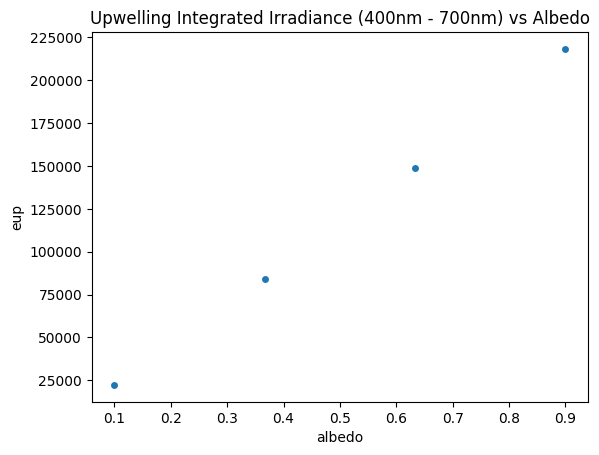

In [3]:
ds_sim.sel(altitude=0).plot.scatter(
    x = 'albedo',
    y = 'eup'
)
plt.title('Upwelling Integrated Irradiance (400nm - 700nm) vs Albedo')
plt.show()